In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_9.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.03332070028308247, 0.9900285714285715)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.30436424186080696, 0.9108)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

airplane      0.990539
automobile    0.997698
bird          0.988140
cat           0.962719
deer          0.993444
dog           0.984840
frog          0.998014
horse         0.994576
ship          0.996065
truck         0.994007
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(5).index.map(trainset.dataset.classess)]
targetF

[3, 5, 2, 0, 4]

In [17]:
targetF=[5,3,6,7]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(14010, 20990)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3951, 6049)

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [22]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision" or data_name=='T' or data_name=='F'):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model



Epoch=0,train_loss=0.007152909209070328,train_accu=0.9983142857142857
Epoch=0,valid_loss=0.1048792186819017,valid_accu=0.9647
0
Epoch=1,train_loss=0.0026989485559046444,train_accu=0.9994
Epoch=1,valid_loss=0.12656853438668186,valid_accu=0.9664
0
Epoch=2,train_loss=0.0022276873186904723,train_accu=0.9994
Epoch=2,valid_loss=0.13937054501067322,valid_accu=0.9668
0
Epoch=3,train_loss=0.0023423056528203558,train_accu=0.9994571428571428
Epoch=3,valid_loss=0.16160939073162153,valid_accu=0.9643
Epoch=4,train_loss=0.0005313569079901234,train_accu=0.9998857142857143
Epoch=4,valid_loss=0.16154724106090343,valid_accu=0.9678
0
Epoch=5,train_loss=0.000522109958793145,train_accu=0.9999142857142858
Epoch=5,valid_loss=0.18715264540617882,valid_accu=0.9652
Epoch=6,train_loss=0.0013183247723305425,train_accu=0.9996571428571429
Epoch=6,valid_loss=0.18574775222097487,valid_accu=0.9646
Epoch=7,train_loss=0.00023370919288299448,train_accu=0.9999428571428571
Epoch=7,valid_loss=0.19172332003516,valid_accu=0.96

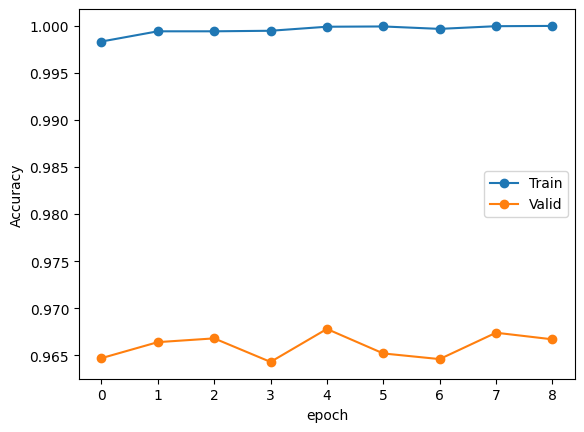

In [23]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [24]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.03260001108529984,train_accu=0.9893758932825155
Epoch=0,valid_loss=0.20898723269488362,valid_accu=0.9444536286989585
0
Epoch=1,train_loss=0.0321861368851588,train_accu=0.9895188184849929
Epoch=1,valid_loss=0.24173269086846788,valid_accu=0.9383369151925938
Epoch=2,train_loss=0.027622977734586423,train_accu=0.9907575035731301
Epoch=2,valid_loss=0.20977331720665773,valid_accu=0.9404860307488841
Epoch=3,train_loss=0.010515796805262963,train_accu=0.9964745116722249
Epoch=3,valid_loss=0.19441037264117605,valid_accu=0.9472640105802612
0
Epoch=4,train_loss=0.015755381668208363,train_accu=0.9948546927108147
Epoch=4,valid_loss=0.1955170285428875,valid_accu=0.9447842618614647
Epoch=5,train_loss=0.015151892571728685,train_accu=0.9950452596474512
Epoch=5,valid_loss=0.22060694983959594,valid_accu=0.9432964126301868
Epoch=6,train_loss=0.028581232703372966,train_accu=0.9908051453072891
Epoch=6,valid_loss=0.25702905608773036,valid_accu=0.9376756488675814
Epoch=7,train_loss=0.012332

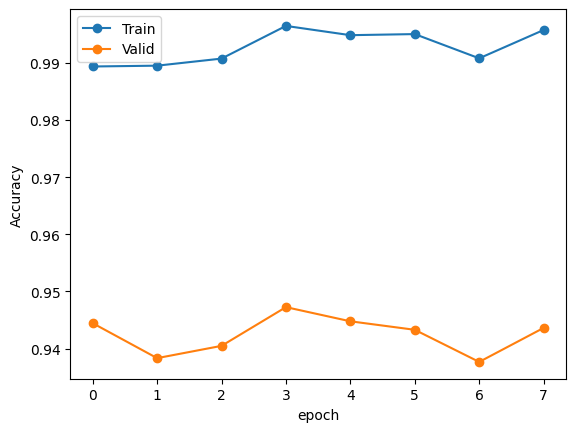

In [25]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [26]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.04187358353768265,train_accu=0.9875802997858673
Epoch=0,valid_loss=0.2671427844717846,valid_accu=0.9124272336117438
0
Epoch=1,train_loss=0.0225439827395623,train_accu=0.9924339757316203
Epoch=1,valid_loss=0.27911690893172614,valid_accu=0.9139458364970894
0
Epoch=2,train_loss=0.030983060393096888,train_accu=0.9908636688079943
Epoch=2,valid_loss=0.2821611654427316,valid_accu=0.9174892432295622
0
Epoch=3,train_loss=0.02326125246710099,train_accu=0.992790863668808
Epoch=3,valid_loss=0.30951476672825046,valid_accu=0.9202733485193622
0
Epoch=4,train_loss=0.02384988048893641,train_accu=0.9935046395431835
Epoch=4,valid_loss=0.2642577699968043,valid_accu=0.911921032649962
Epoch=5,train_loss=0.009858446689435599,train_accu=0.9971448965024983
Epoch=5,valid_loss=0.2646022934265769,valid_accu=0.9245760566945077
0
Epoch=6,train_loss=0.015267493350924572,train_accu=0.9947894361170593
Epoch=6,valid_loss=0.30308505500895677,valid_accu=0.9121741331308529
Epoch=7,train_loss=0.0438048

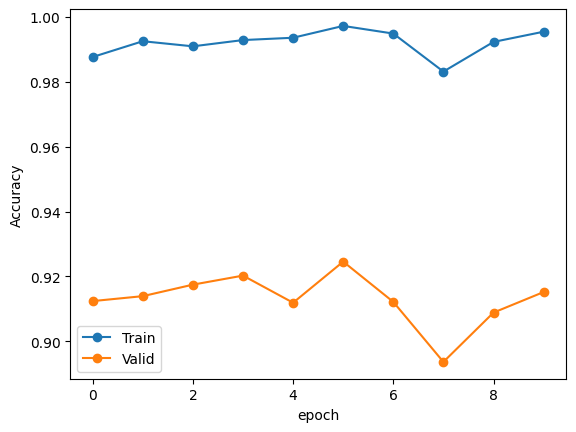

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0005313569079901234, 0.9998857142857143)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.16154724106090343, 0.9678)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.011275175649101153, 0.9964745116722249)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.008500231458369421, 0.9979300499643112)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.20154104860994337, 0.9477599603240205)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.25914268498857, 0.9228043533282714)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.010425307030202488, 0.9969428571428571, 14010)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.22703347621369174, 0.9386, 3951)

In [36]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.03493857656004839, 0.9956857142857143, 14037, 20963)

In [37]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.6725253246845677, 0.9155, 4004, 5996)

In [38]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [39]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.033321,0.990029,0.304364,0.910800
1,Model_Decision,0.000531,0.999886,0.161547,0.967800
2,Model_T,0.011275,0.996475,0.201541,0.947760
3,Model_F,0.008500,0.997930,0.259143,0.922804
4,Total_Model,0.034939,0.995686,0.672525,0.915500
5,Total_Model_without_decision,0.010425,0.996943,0.227033,0.938600


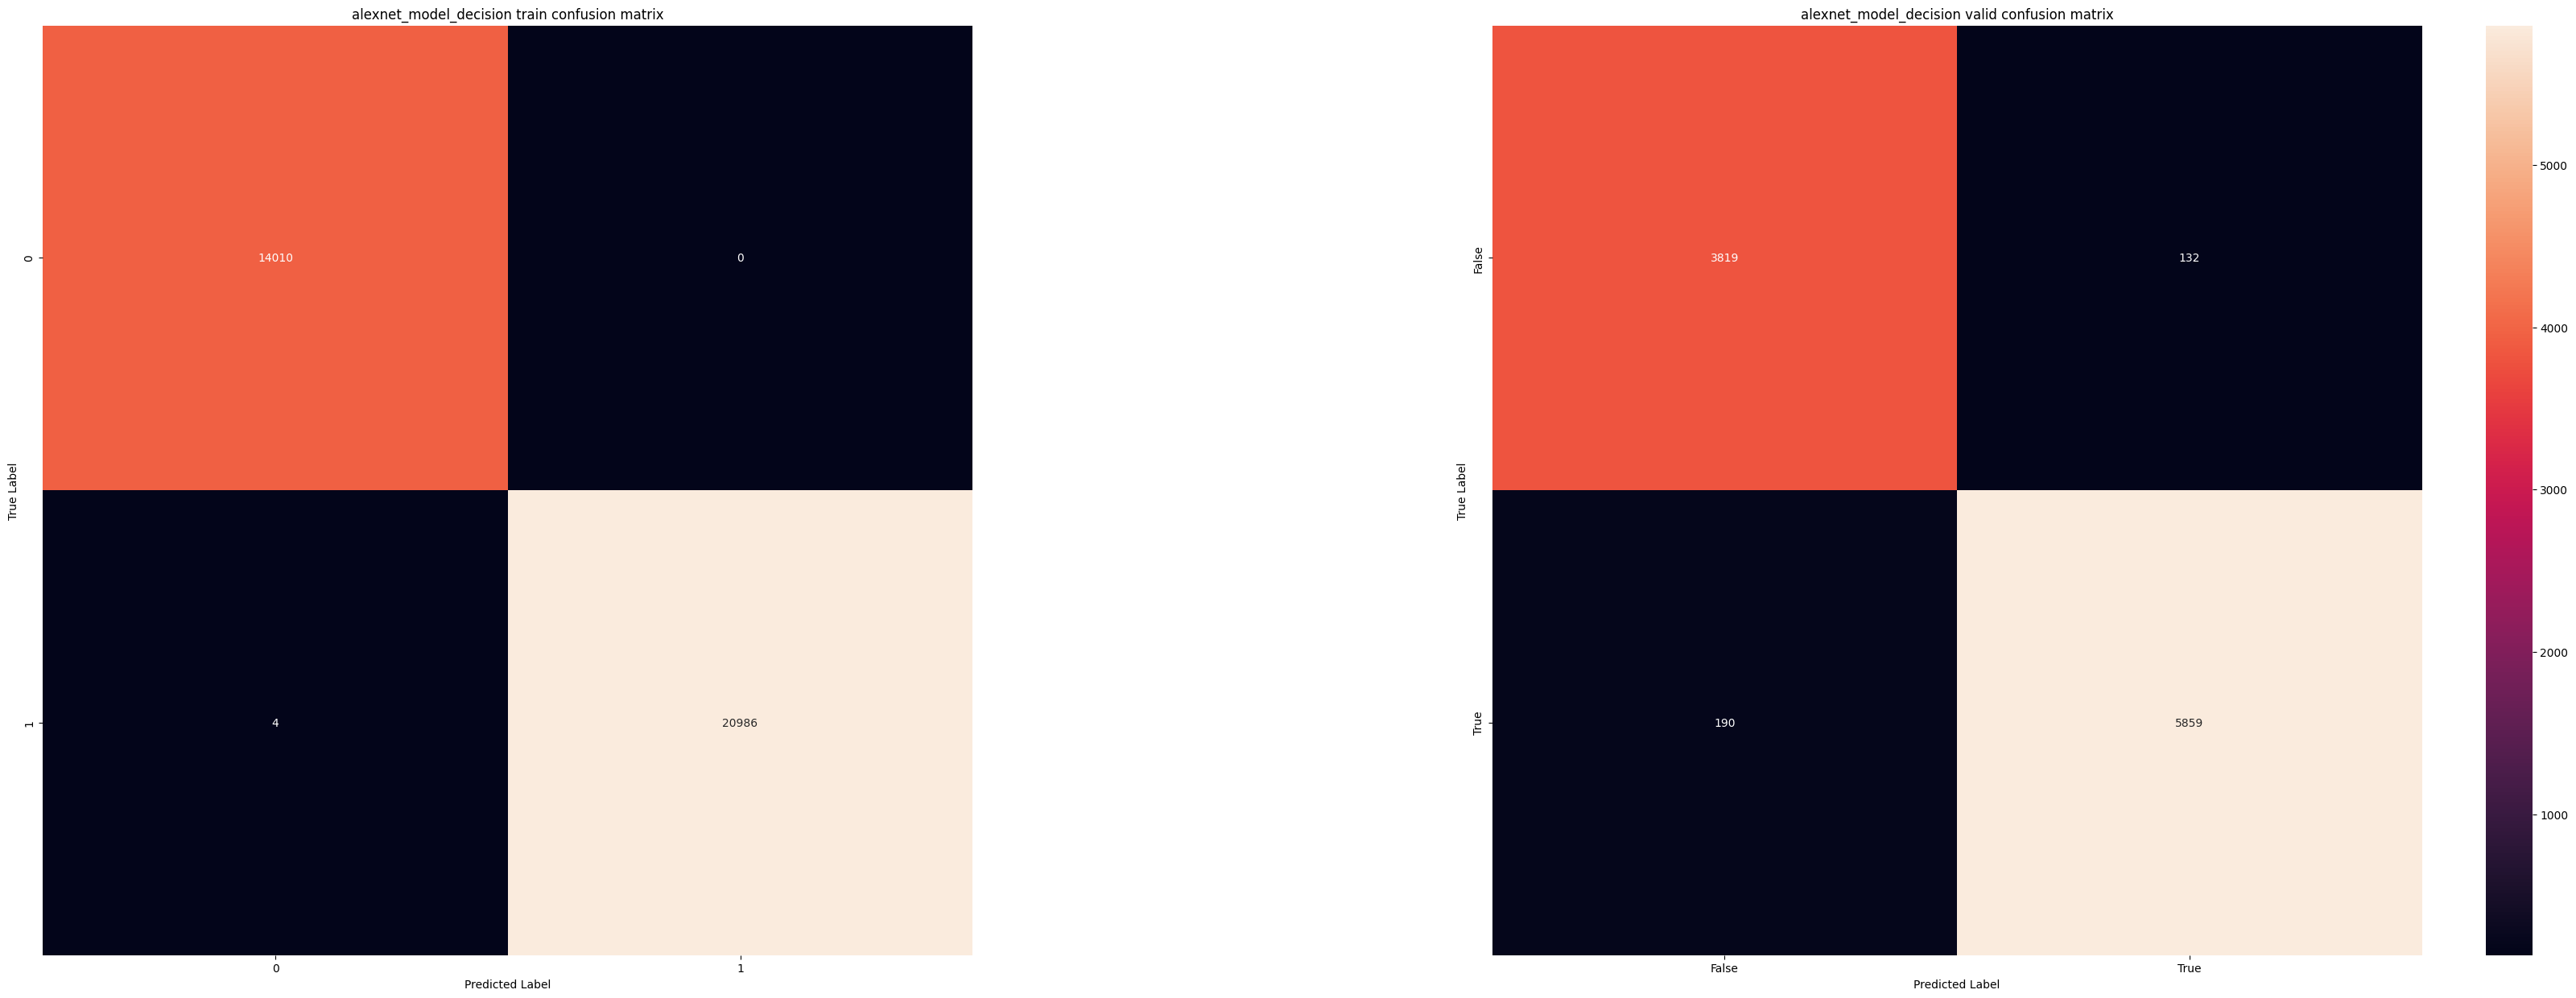

In [40]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

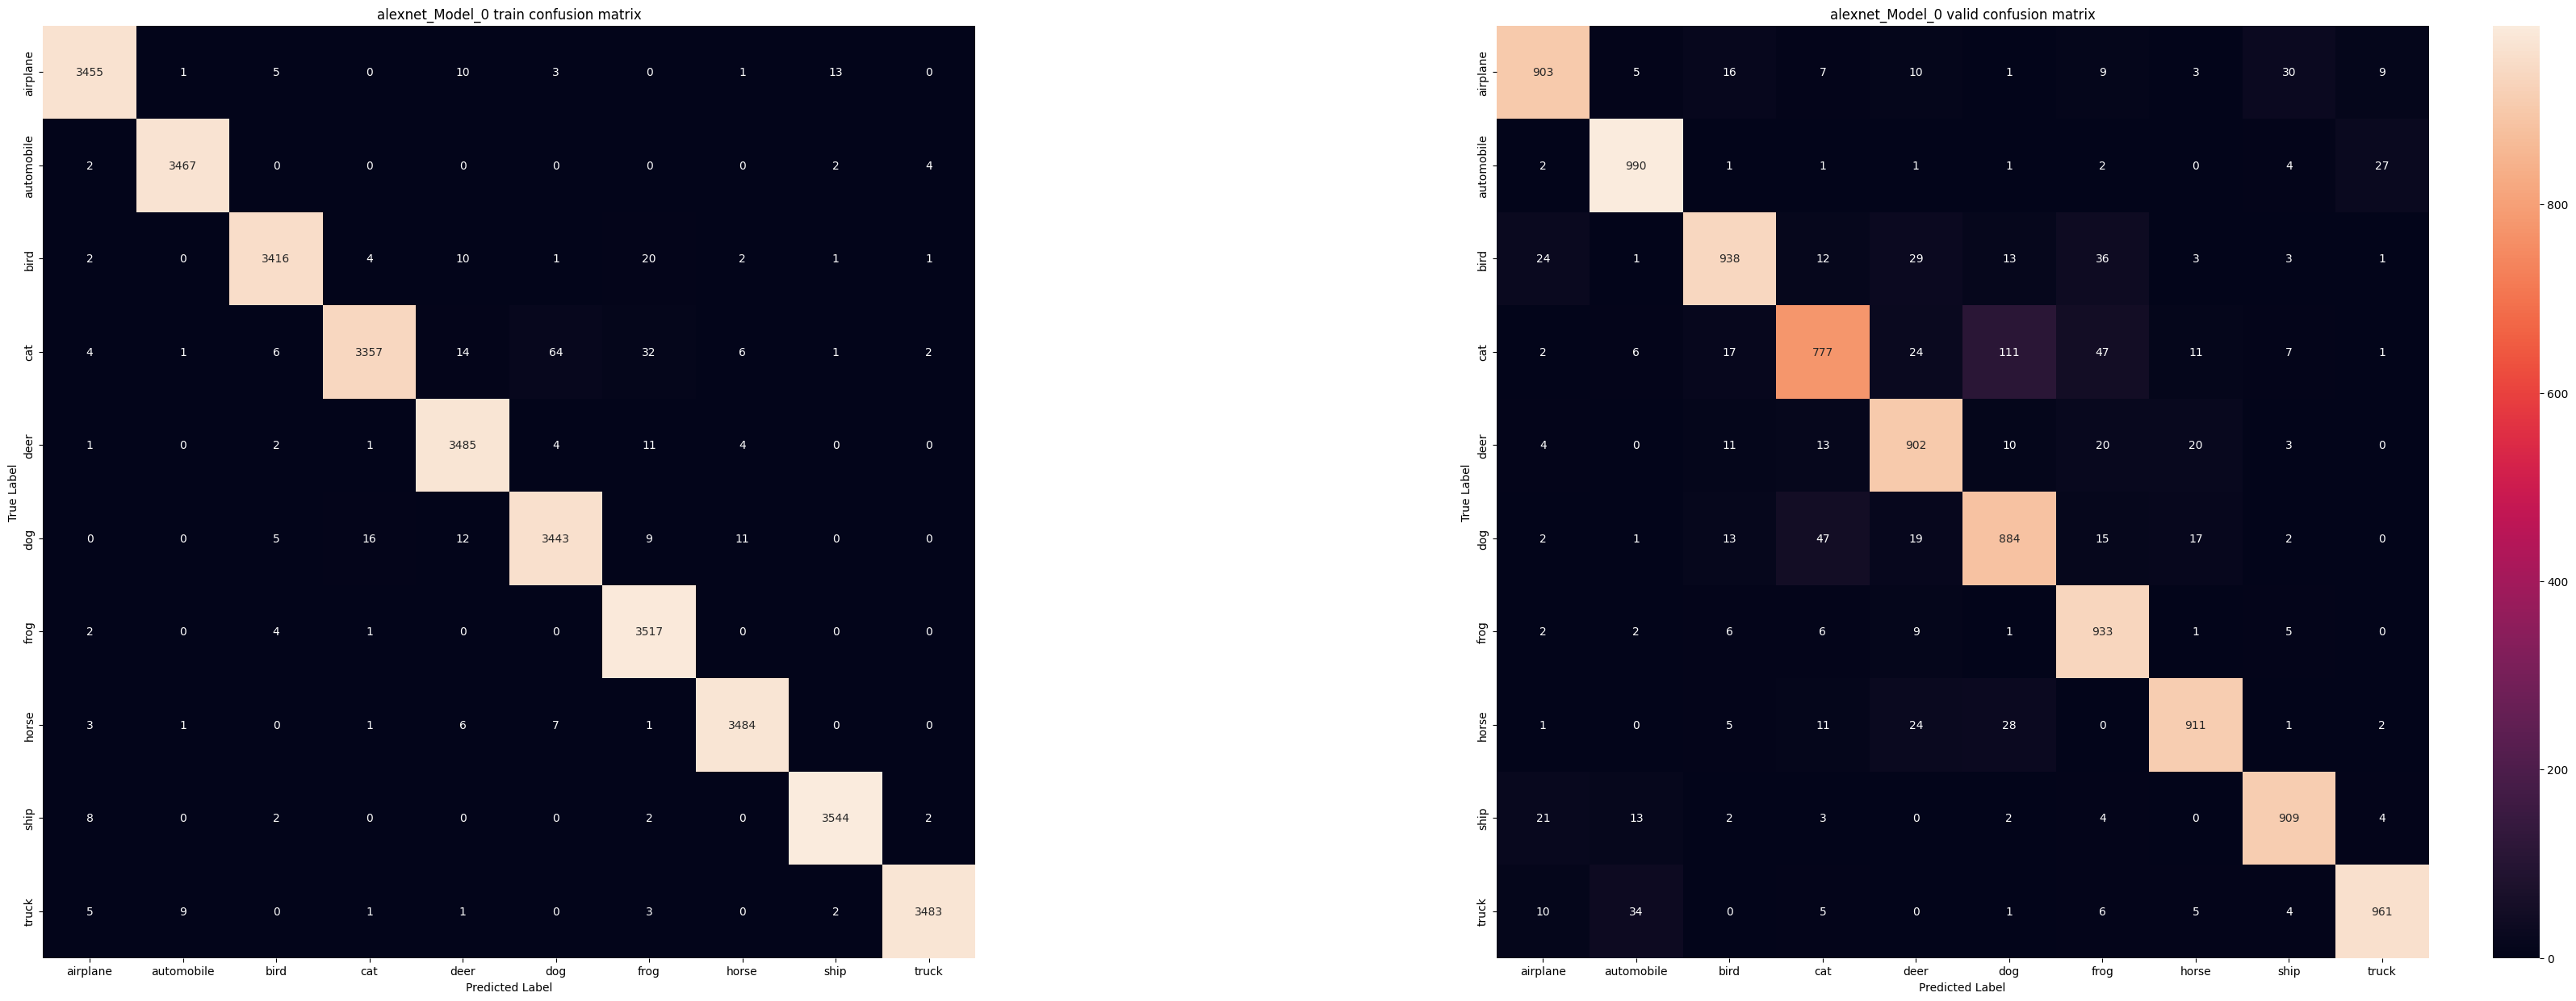

In [41]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [42]:
n_classes = confusion_matrix_train.shape[0]
confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
for i in range(n_classes):
    for j in range(n_classes):
        if i != j:
            degree = (confusion_matrix_total_train.iloc[i, j] / np.sum(confusion_matrix_total_train.iloc[i])) + \
                     (confusion_matrix_total_train.iloc[j, i] / np.sum(confusion_matrix_total_train.iloc[j]))
            confusion_degrees[i, j] = degree
N = 7
# 只检查下三角的元素
indices = np.tril_indices_from(confusion_degrees, k=-1)
flat_indices = np.argsort(confusion_degrees[indices])[-N:]
row_indices = indices[0][flat_indices]
col_indices = indices[1][flat_indices]

print("Top", N, "Elements:")
print(confusion_degrees[row_indices, col_indices])
print("Top", N, "Positions:")
print(' ',row_indices,'\n', col_indices)

Top 7 Elements:
[0.00201741 0.00256638 0.00256948 0.00339524 0.00343657 0.00404461
 0.00572968]
Top 7 Positions:
  [3 7 5 8 9 2 5] 
 [2 4 4 0 1 0 3]


In [43]:
n_classes = confusion_matrix_valid.shape[0]
confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
for i in range(n_classes):
    for j in range(n_classes):
        if i != j:
            degree = (confusion_matrix_total_train.iloc[i, j] / np.sum(confusion_matrix_total_train.iloc[i])) + \
                     (confusion_matrix_total_train.iloc[j, i] / np.sum(confusion_matrix_total_train.iloc[j]))
            confusion_degrees[i, j] = degree
            
N = 4
# 只检查下三角的元素
indices = np.tril_indices_from(confusion_degrees, k=-1)
flat_indices = np.argsort(confusion_degrees[indices])[-N:]
row_indices = indices[0][flat_indices]
col_indices = indices[1][flat_indices]

print("Top", N, "Elements:")
print(confusion_degrees[row_indices, col_indices])
print("Top", N, "Positions:")
print(' ',row_indices,'\n', col_indices)

Top 4 Elements:
[0.00339524 0.00343657 0.00404461 0.00572968]
Top 4 Positions:
  [8 9 2 5] 
 [0 1 0 3]


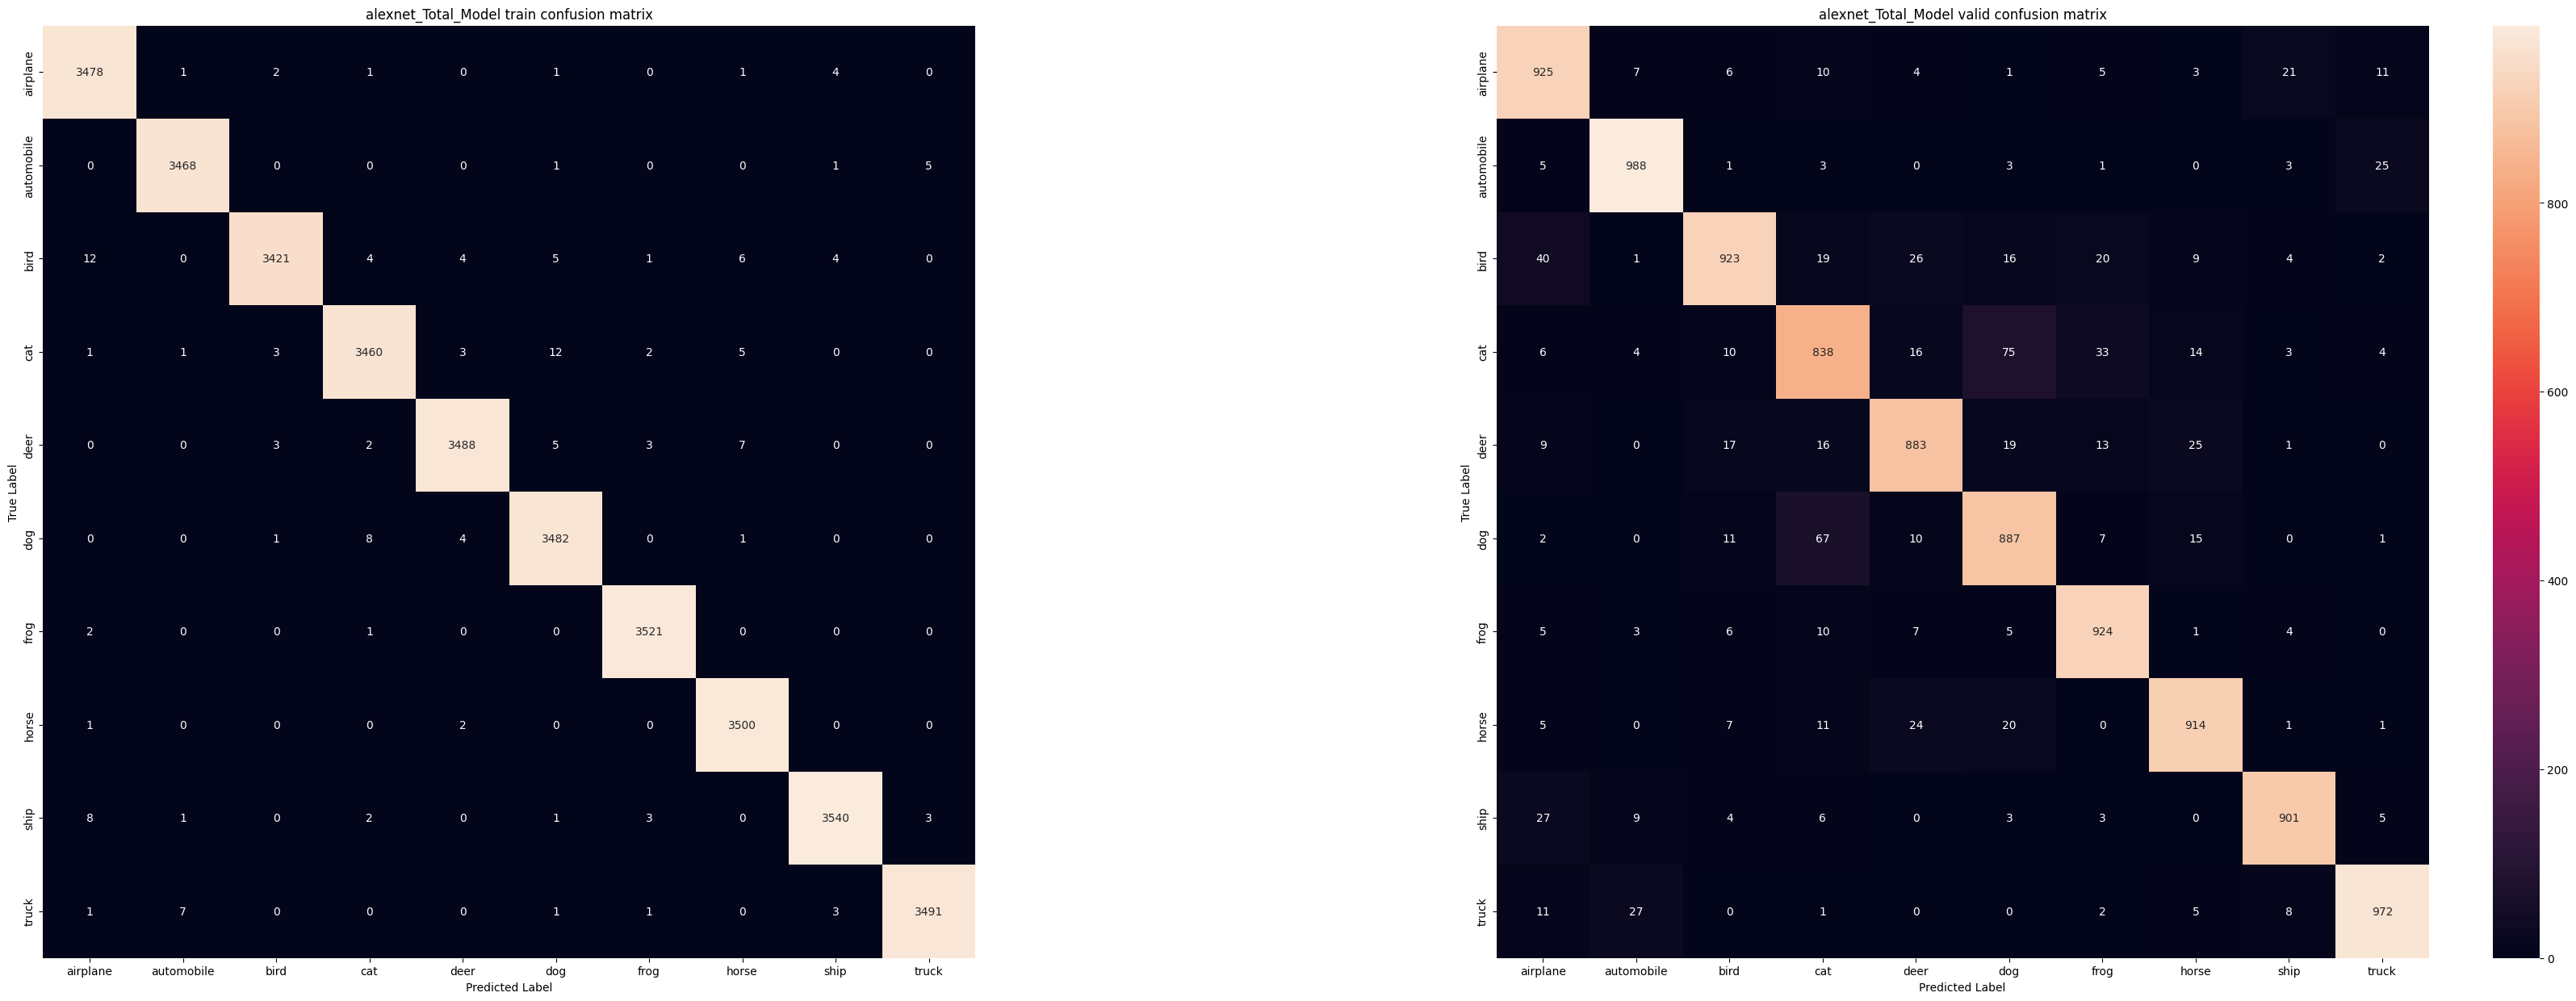

In [44]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

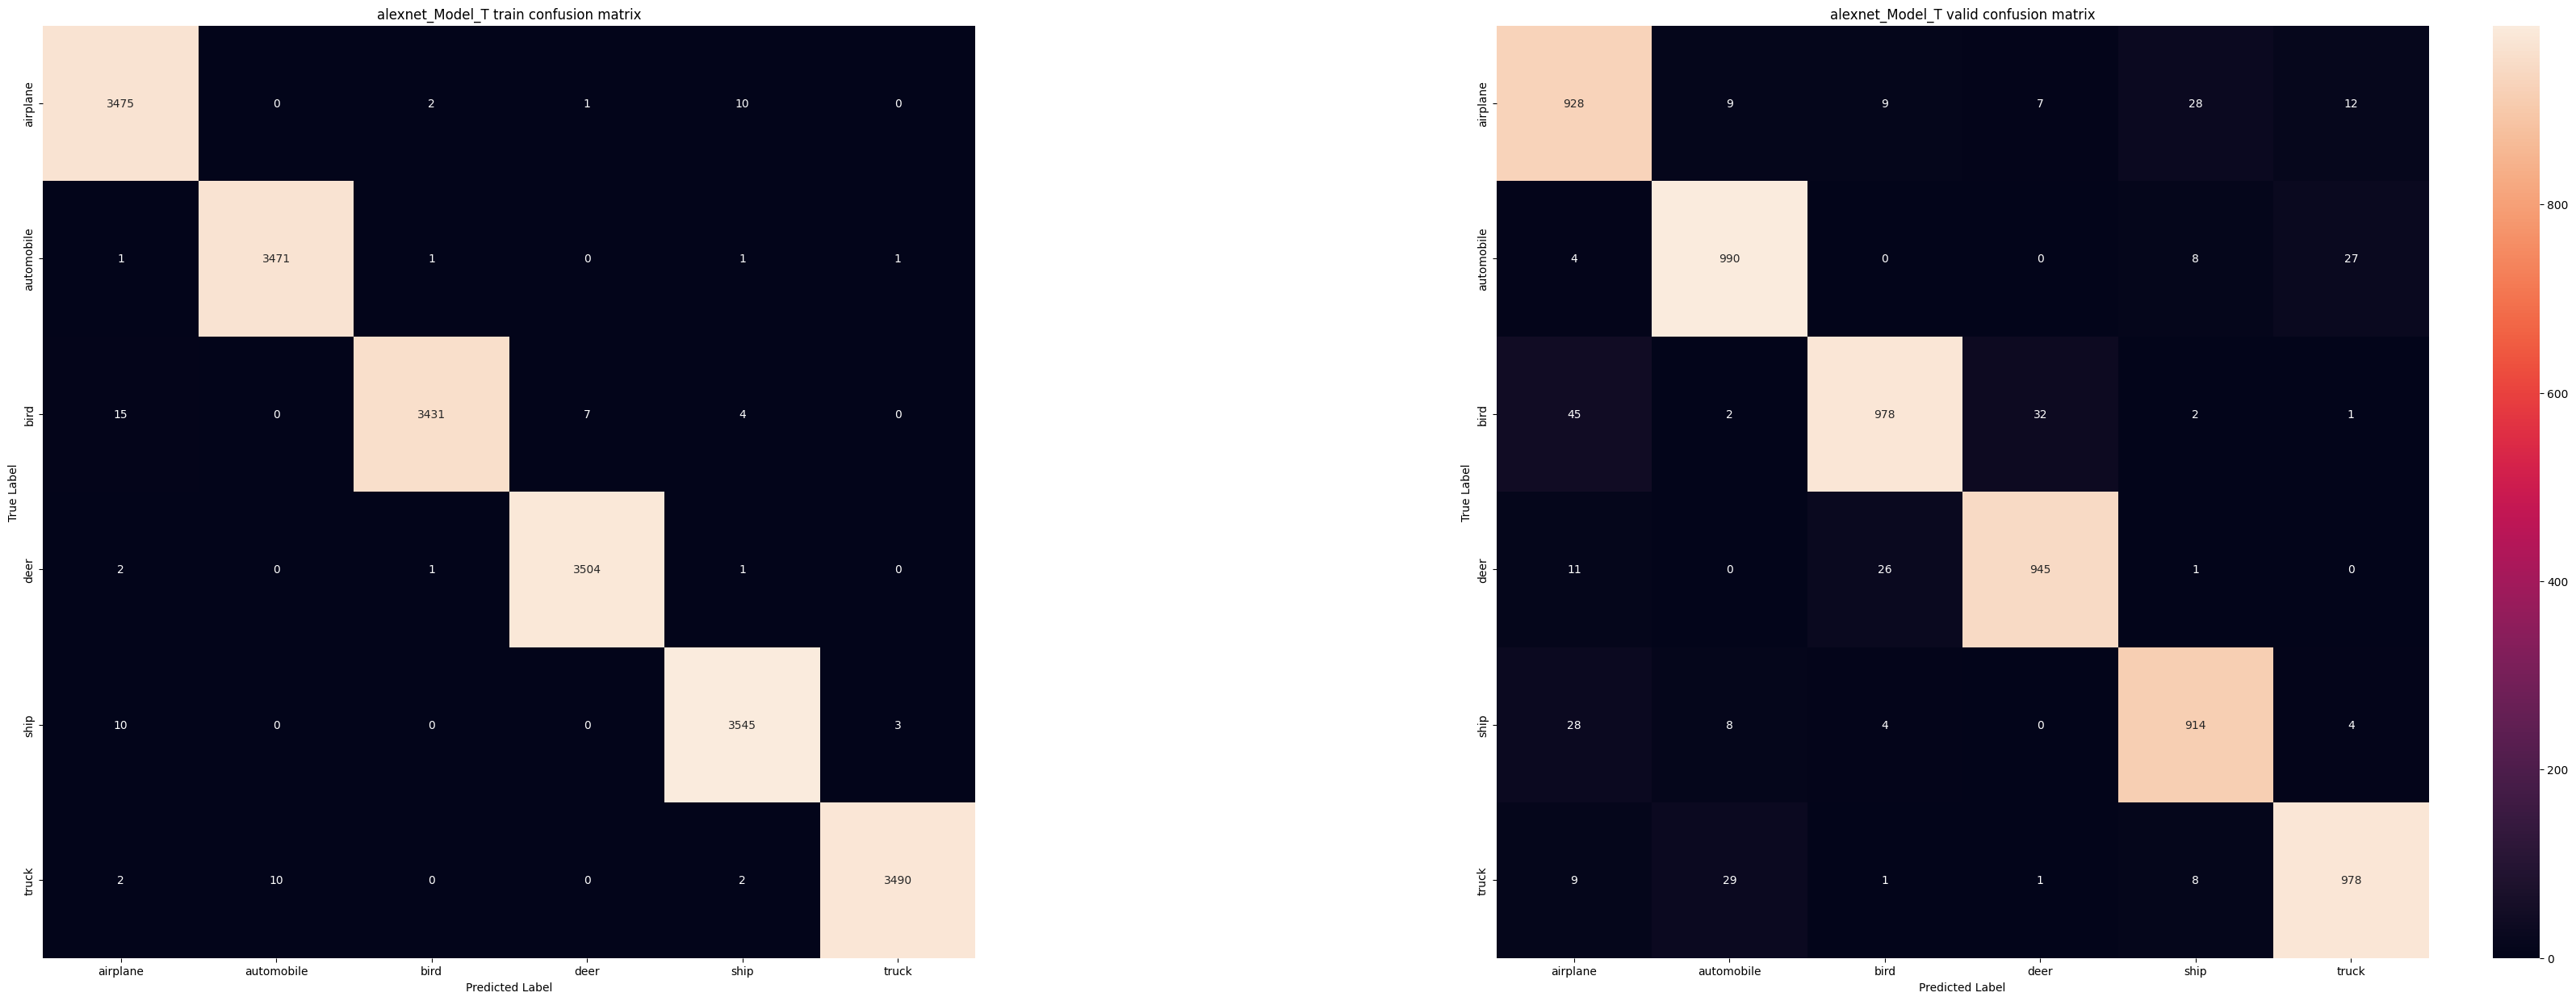

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

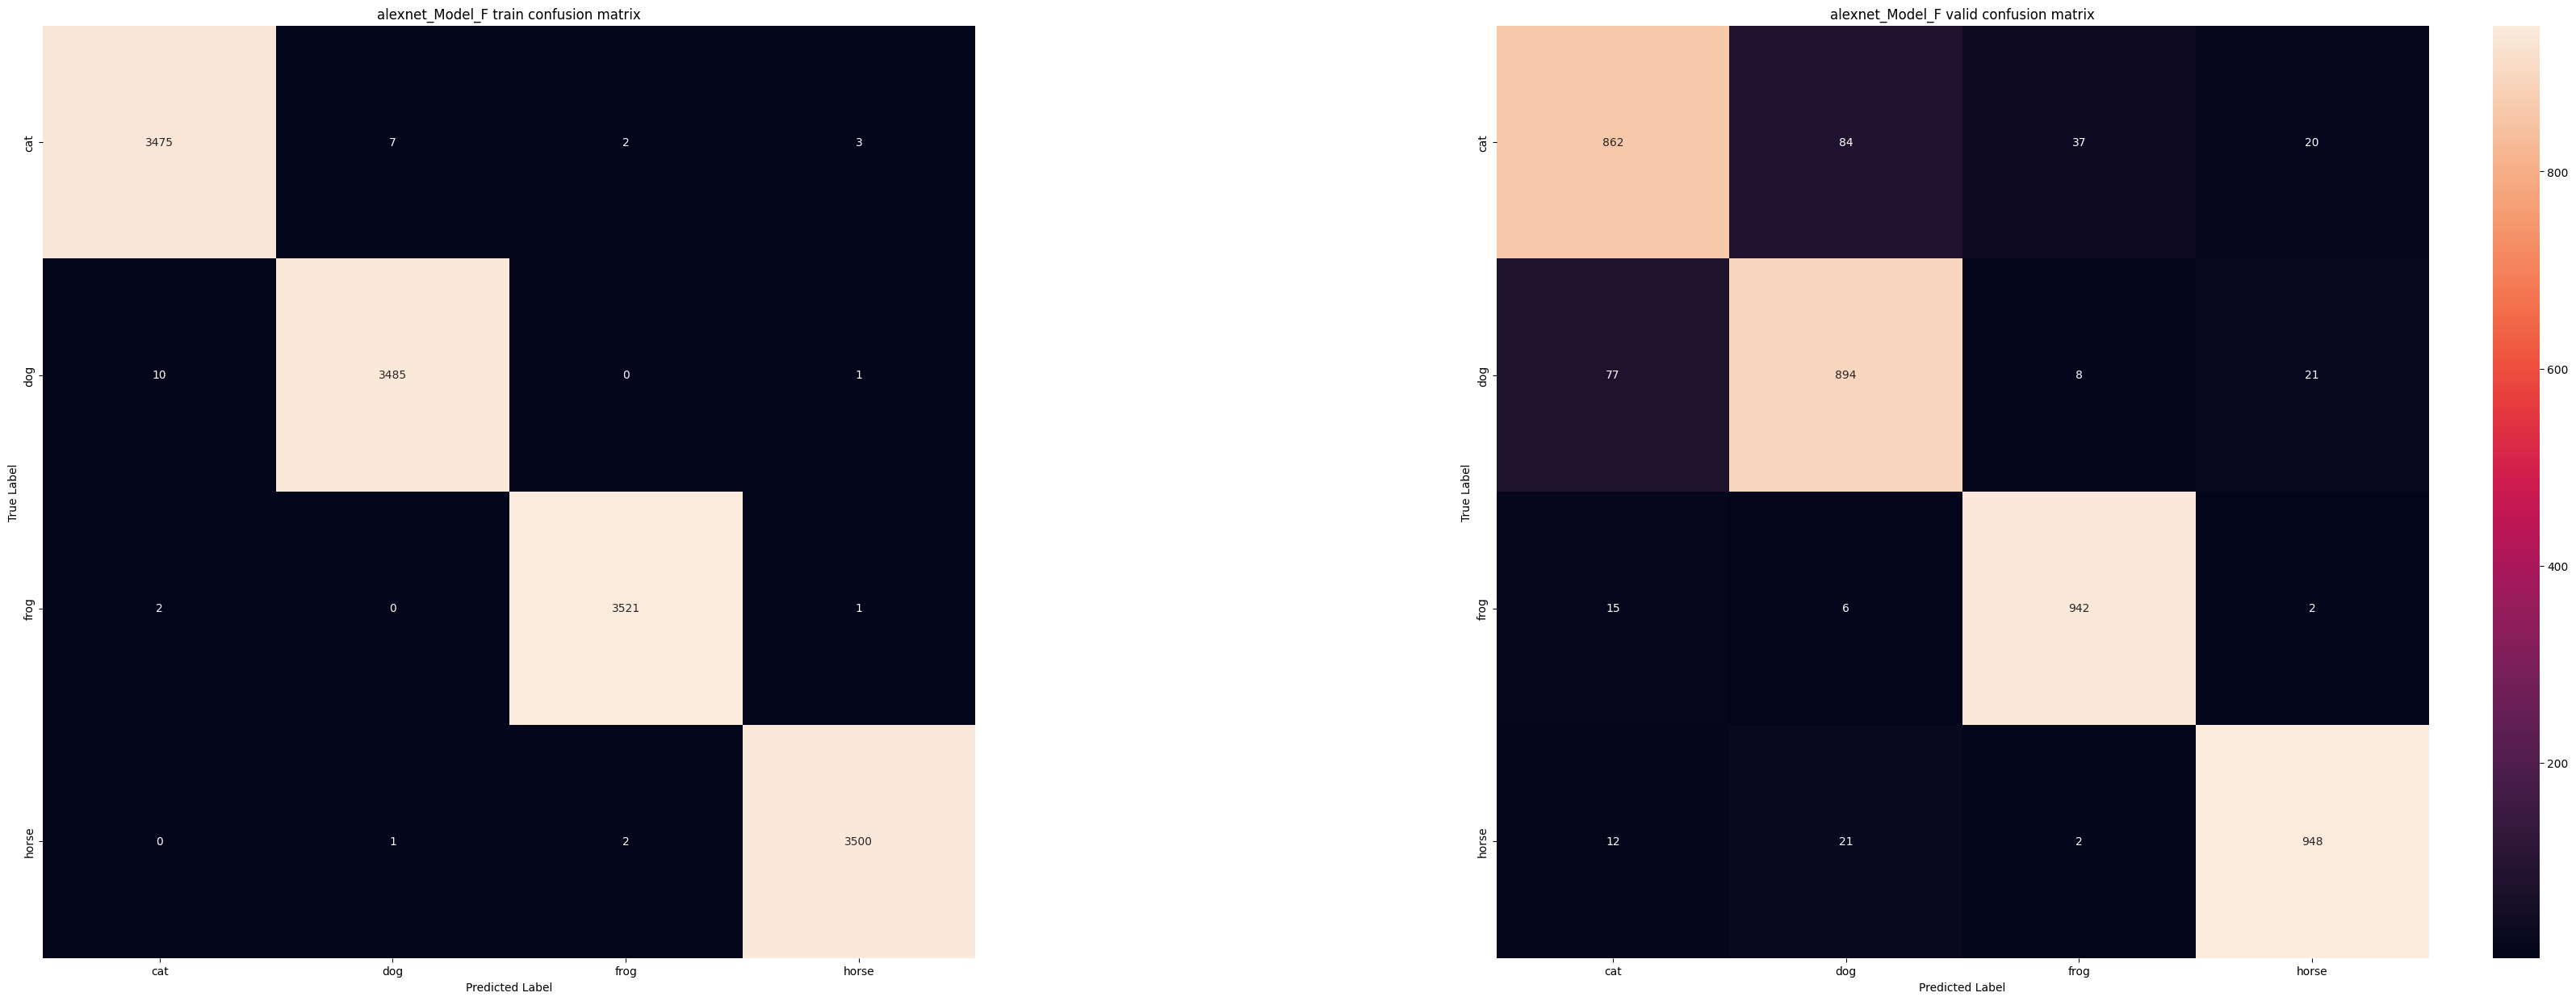

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [47]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [48]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,47797,3,3,9,3,0.941201,0.680177,0.950354,1.0,True,False,True,False,False
1,47095,5,5,2,5,1.000000,0.999997,0.999999,1.0,True,False,True,False,False
2,7901,5,5,4,5,1.000000,0.999997,0.999966,1.0,True,False,True,False,False
3,27151,9,3,9,9,0.871644,1.000000,1.000000,1.0,False,True,True,True,True
4,28735,7,7,4,7,1.000000,0.999946,1.000000,1.0,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,2365,0,6,0,0,0.563191,0.999889,0.999357,1.0,False,True,True,True,True
34996,42822,8,5,8,8,0.793500,1.000000,0.999998,1.0,False,True,True,True,True
34997,19175,8,6,8,8,0.999689,0.918270,0.980271,1.0,False,True,True,True,True
34998,12936,0,7,0,0,0.641994,1.000000,0.999945,1.0,False,True,True,True,True


In [49]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
192,31169,2,6,2,6,0.491050,0.999278,0.840232,0.558787,False,True,False,False,True
211,22913,3,3,2,2,0.999927,0.982186,0.653101,0.973639,True,False,False,True,False
778,8024,2,6,2,6,1.000000,0.998999,0.995923,0.526103,False,True,False,False,True
1369,7062,4,6,4,6,0.976194,0.937112,0.749335,0.918683,False,True,False,False,True
1635,33345,3,3,2,3,0.999996,0.981158,0.869130,0.912678,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32633,14715,2,6,2,2,0.914955,0.995670,0.636408,0.890867,False,True,True,False,True
33378,30638,4,7,4,4,0.965917,0.999996,0.981634,0.842342,False,True,True,False,True
33572,33517,6,6,4,6,0.999087,0.521957,0.878199,0.873431,True,False,True,True,False
34019,8726,2,7,2,7,0.974840,0.999990,0.978467,0.987741,False,True,False,False,True


In [50]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

2    29
4    21
3    10
5     6
8     4
7     3
9     3
1     3
6     3
0     2
Name: Target, dtype: int64

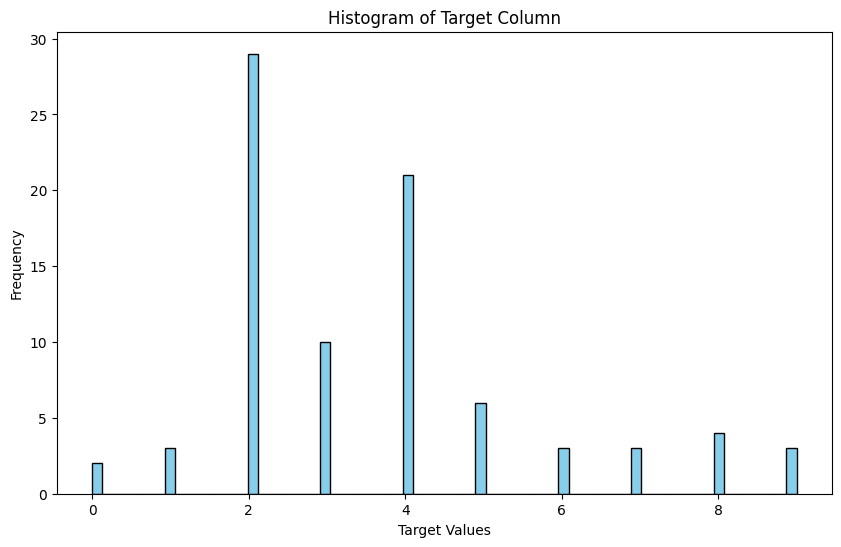

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [52]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

10

In [53]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

32

In [54]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
192,31169,2,6,2,6,0.491050,0.999278,0.840232,0.558787,False,True,False,False,True
778,8024,2,6,2,6,1.000000,0.998999,0.995923,0.526103,False,True,False,False,True
2002,49199,4,5,4,4,0.985397,0.999992,0.629224,0.604237,False,True,True,False,True
2839,49990,4,5,4,4,0.877146,0.999994,0.673217,0.688752,False,True,True,False,True
4097,26900,3,3,4,3,0.974299,0.879530,0.842305,0.503390,True,False,True,True,False
4511,26605,2,3,2,2,0.970298,0.999783,0.933185,0.598826,False,True,True,False,True
5425,42946,5,5,4,4,0.994945,0.999607,0.840940,0.899463,True,False,False,True,False
5933,39739,0,3,0,0,0.963565,0.999954,0.951634,0.772947,False,True,True,False,True
6272,346,4,7,4,5,0.990680,0.979924,0.476506,0.860926,False,True,False,False,True
6672,621,4,7,4,4,0.695691,0.999708,0.622542,0.578647,False,True,True,False,True


In [55]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,47575,7,7,2,7,0.999999,0.903305,0.999999,1.0,True,False,True,False,False
1,13273,2,6,2,2,0.961511,0.999999,0.953771,1.0,False,True,True,True,True
2,35658,0,3,0,0,0.757537,0.997463,0.993140,1.0,False,True,True,True,True
3,36557,9,5,9,9,0.464374,1.000000,0.999854,1.0,False,True,True,True,True
4,18120,9,6,9,9,0.471815,1.000000,1.000000,1.0,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10422,7,7,4,7,1.000000,0.999999,1.000000,1.0,True,False,True,False,False
9996,23220,1,6,1,1,0.640197,1.000000,1.000000,1.0,False,True,True,True,True
9997,24400,1,6,1,1,0.501320,1.000000,0.999999,1.0,False,True,True,True,True
9998,9122,8,3,8,8,0.702301,1.000000,1.000000,1.0,False,True,True,True,True


In [56]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

26

In [57]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

37

In [58]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
13,7083,8,6,8,6,0.999993,0.822297,0.648434,0.991909,False,True,False,False,True
54,2974,8,3,8,8,0.964180,0.999710,0.611609,0.995239,False,True,True,False,True
59,10926,2,6,2,6,1.000000,0.999911,0.999969,0.999828,False,True,False,False,True
84,14857,4,6,4,6,0.991467,0.917551,0.887428,0.999321,False,True,False,False,True
116,14330,3,5,0,2,0.749402,0.520060,0.281231,0.632497,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9881,16222,4,6,4,6,0.999992,0.981583,0.998734,0.999584,False,True,False,False,True
9894,45667,3,3,4,4,0.998535,0.998548,0.730110,0.995657,True,False,False,True,False
9912,22461,4,7,4,4,0.998338,0.786239,0.484822,0.779255,False,True,True,False,True
9960,24565,3,3,2,2,0.986902,0.982078,0.451472,0.842525,True,False,False,True,False


In [59]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

4    80
2    60
3    49
7    32
6    26
5    23
0    20
8    11
9     6
1     6
Name: Target, dtype: int64

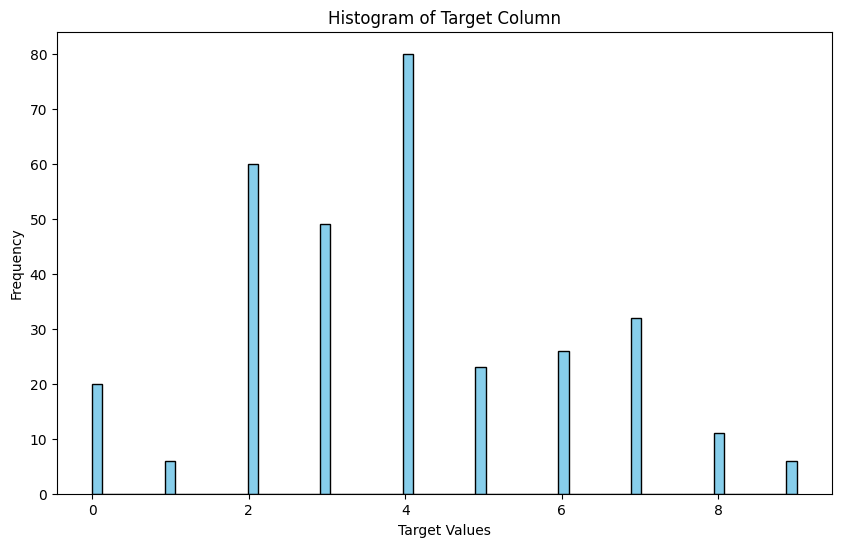

In [60]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [61]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
116,14330,3,5,0,2,0.749402,0.520060,0.281231,0.632497,False,False,False,True,False
154,35151,4,7,4,5,0.419930,0.759606,0.674233,0.999608,False,True,False,False,True
346,4447,4,7,4,7,0.777349,0.999917,0.735065,0.996067,False,True,False,False,True
487,13527,5,5,0,0,0.441170,0.971106,0.479342,0.999743,True,False,False,True,False
490,24389,6,6,8,8,0.748811,0.995856,0.952473,0.853103,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9549,29980,0,5,0,0,0.515098,0.999057,0.862745,0.949437,False,True,True,False,True
9552,22487,5,7,4,4,0.727696,0.996366,0.789848,0.736740,False,False,False,True,False
9556,28497,2,7,4,7,0.999743,0.671944,0.972579,0.999645,False,False,False,False,True
9686,13522,0,7,8,6,0.461332,0.874048,0.970002,0.683579,False,False,False,False,True


In [62]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
13,7083,8,6,8,6,0.999993,0.822297,0.648434,0.991909,False,True,False,False,True
54,2974,8,3,8,8,0.964180,0.999710,0.611609,0.995239,False,True,True,False,True
59,10926,2,6,2,6,1.000000,0.999911,0.999969,0.999828,False,True,False,False,True
84,14857,4,6,4,6,0.991467,0.917551,0.887428,0.999321,False,True,False,False,True
116,14330,3,5,0,2,0.749402,0.520060,0.281231,0.632497,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9881,16222,4,6,4,6,0.999992,0.981583,0.998734,0.999584,False,True,False,False,True
9894,45667,3,3,4,4,0.998535,0.998548,0.730110,0.995657,True,False,False,True,False
9912,22461,4,7,4,4,0.998338,0.786239,0.484822,0.779255,False,True,True,False,True
9960,24565,3,3,2,2,0.986902,0.982078,0.451472,0.842525,True,False,False,True,False


In [63]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [64]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [65]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.05932776165559522, 0.9940571428571429, 14047, 20953)

In [66]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.8467497445639223, 0.9111, 3955, 6045)